In [87]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = pd.read_csv('/Users/akshithreddy/Desktop/Projects/F1_2026/Data/results.csv')
drivers = pd.read_csv('/Users/akshithreddy/Desktop/Projects/F1_2026/Data/drivers.csv')
races   = pd.read_csv('/Users/akshithreddy/Desktop/Projects/F1_2026/Data/races.csv')

# Merge everything into one clean table
df = results.merge(races, on='raceId').merge(drivers, on='driverId')

# Filter to 2023 only
df_2023 = df[df['year'] == 2023].copy()

# Create a readable driver name column
df_2023['driver_name'] = df_2023['forename'] + ' ' + df_2023['surname']

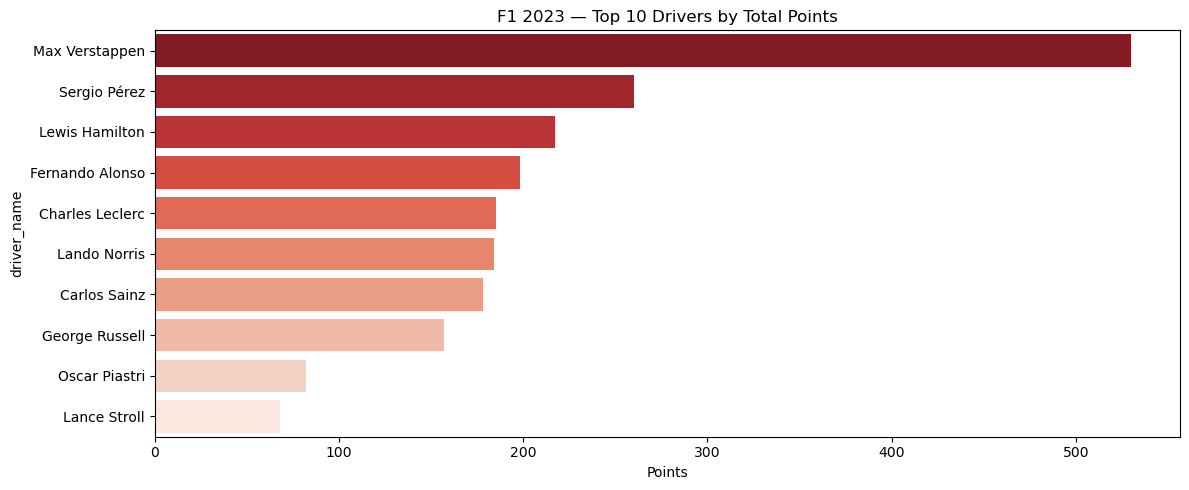

In [89]:
points = df_2023.groupby('driver_name')['points'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=points.values, y=points.index, hue=points.index, palette='Reds_r', legend=False)
plt.title('F1 2023 — Top 10 Drivers by Total Points')
plt.xlabel('Points')
plt.tight_layout()
plt.show()

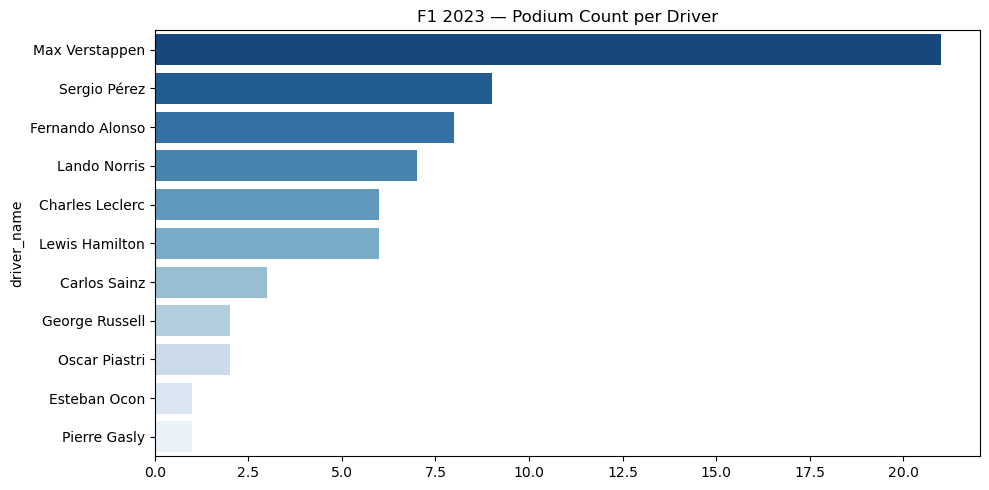

In [90]:
podiums = df_2023[df_2023['positionOrder'] <= 3]
podium_count = podiums.groupby('driver_name')['positionOrder'].count().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=podium_count.values, y=podium_count.index, hue=podium_count.index, palette='Blues_r', legend=False)
plt.title('F1 2023 — Podium Count per Driver')
plt.tight_layout()
plt.show()

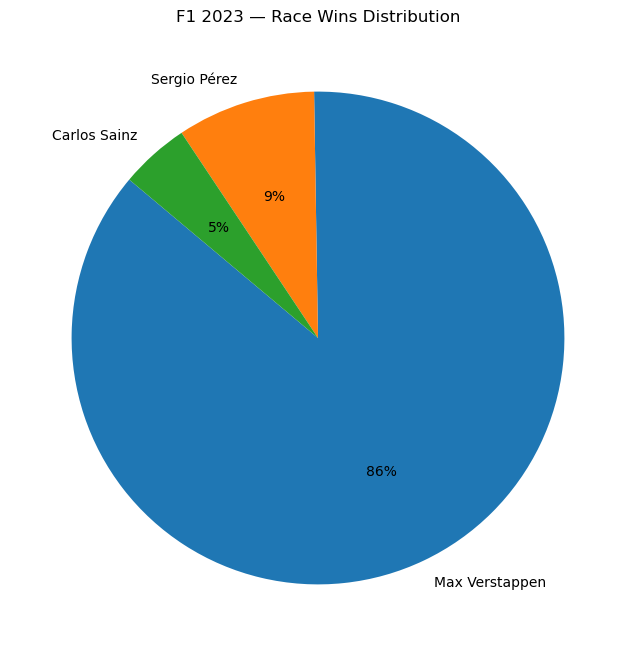

In [91]:
wins = df_2023[df_2023['positionOrder'] == 1]
win_count = wins['driver_name'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(win_count.values, labels=win_count.index, autopct='%1.0f%%', startangle=140)
plt.title('F1 2023 — Race Wins Distribution')
plt.show()

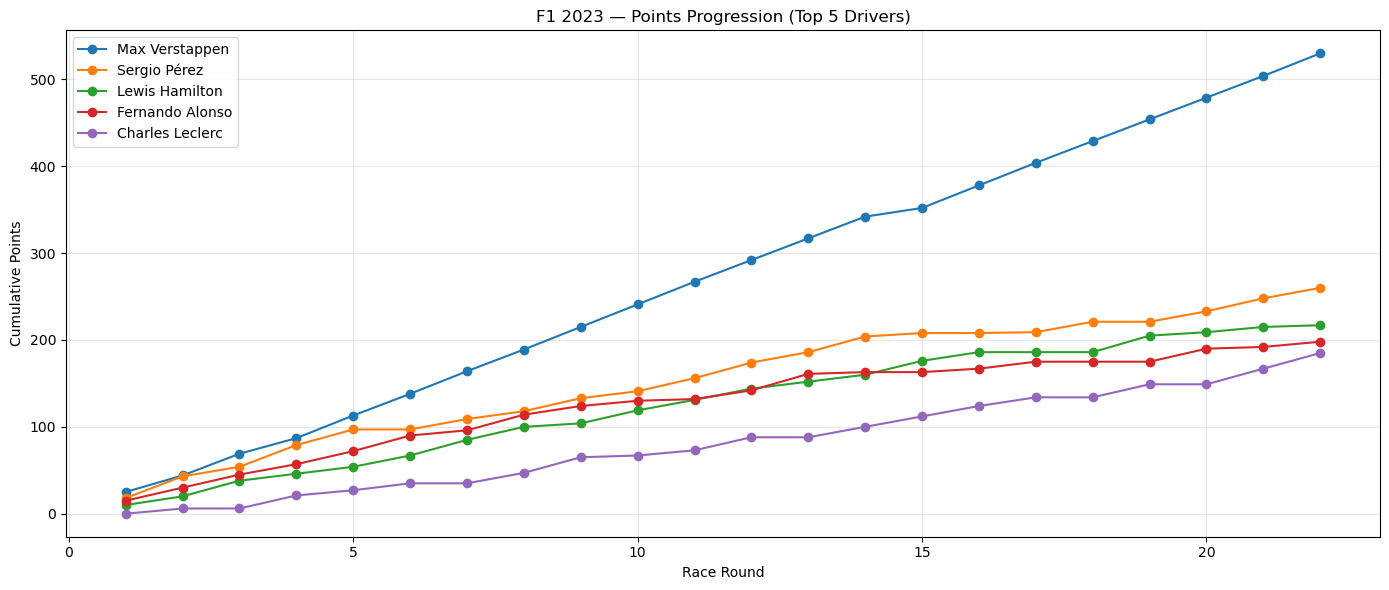

In [92]:
# Cumulative points across the season for top 5 drivers
top5 = points.head(5).index.tolist()
df_top5 = df_2023[df_2023['driver_name'].isin(top5)].sort_values('round')
df_top5['cumulative_points'] = df_top5.groupby('driver_name')['points'].cumsum()

plt.figure(figsize=(14,6))
for driver in top5:
    d = df_top5[df_top5['driver_name'] == driver]
    plt.plot(d['round'], d['cumulative_points'], marker='o', label=driver)

plt.title('F1 2023 — Points Progression (Top 5 Drivers)')
plt.xlabel('Race Round')
plt.ylabel('Cumulative Points')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Verstappen dominated the 2023 season, winning more than 20 races and building an unassailable lead by Round 15. The points progression chart shows the gap opened most dramatically between Rounds 8–12.